<a href="https://colab.research.google.com/github/leopedraza-1/Actividad1/blob/main/Actividad3_DataScience.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Total de registros cargados: 4,754

--- TOP 10 DEPARTAMENTOS CON MÁS CASOS ---
Departamento  Cantidad_de_Casos
      BOGOTA               2217
   ANTIOQUIA               1430
        CALI                388
CUNDINAMARCA                115
   SANTANDER                 95
BARRANQUILLA                 95
   RISARALDA                 68
      TOLIMA                 60
       VALLE                 58
        META                 31


/tmp/ipykernel_7265/4245143393.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


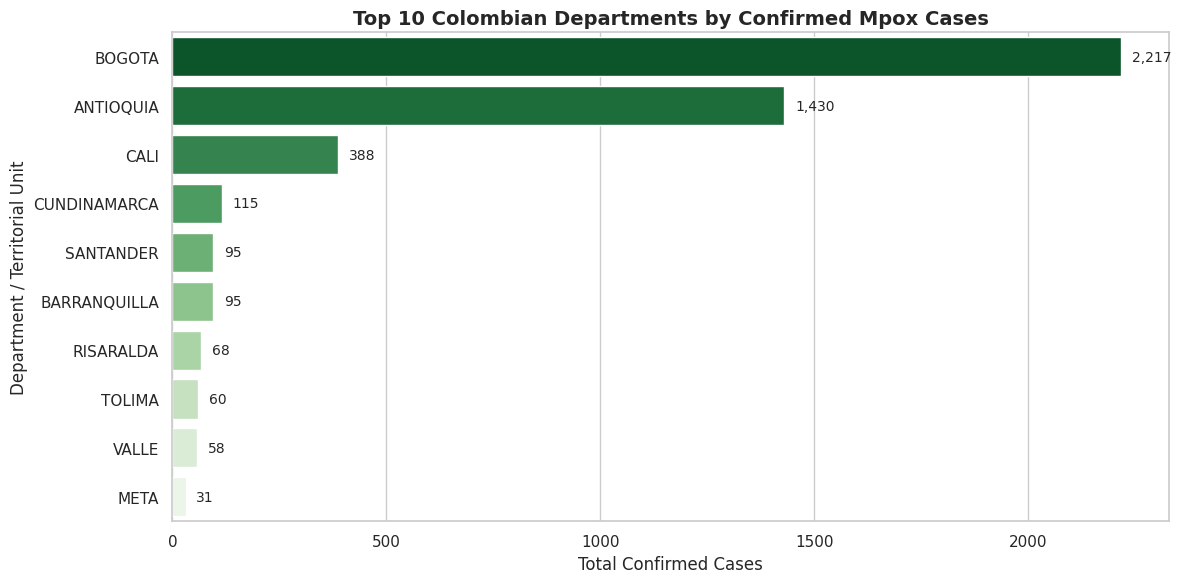

In [17]:
import pandas as pd  # Import pandas library for data loading, cleaning, and manipulation
import matplotlib.pyplot as plt  # Import matplotlib for figure setup and visualization customization
import seaborn as sns  # Import seaborn for modern statistical plots

# Load the dataset
df = pd.read_excel('Casos_positivos_de_Viruela_símica_en_Colombia_20260904.xlsx')
print(f"Total de registros cargados: {len(df):,}")  # Print total number of rows loaded

# Clean and standardize categorical string values
df['Departamento'] = df['Departamento'].astype(str)  # Convert all department values to string data type
df['Departamento'] = df['Departamento'].str.strip()  # Strip trailing and leading whitespace characters
df['Departamento'] = df['Departamento'].str.upper()  # Convert text to uppercase

# Aggregate case counts per department
cases_by_dept = df['Departamento'].value_counts().reset_index()  # Count frequency of cases per department
cases_by_dept.columns = ['Departamento', 'Cantidad_de_Casos']  # Rename aggregated summary columns

# Select the top 10 entities with highest positive case counts
top10_dept = cases_by_dept.head(10)

print("\n--- TOP 10 DEPARTAMENTOS CON MÁS CASOS ---")
print(top10_dept.to_string(index=False))

# Configure graphic parameters
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Build horizontal bar chart
ax = sns.barplot(
    x='Cantidad_de_Casos',  # Assign quantitative case counts to X-axis
    y='Departamento',  # Assign categorical department names to Y-axis
    data=top10_dept,  # Pass top 10 DataFrame as plot data source
    palette='Greens_r'  # Apply dark-to-light sequential blue color gradient
)

# Apply chart labels and title
plt.title('Top 10 Colombian Departments by Confirmed Mpox Cases', fontsize=14, fontweight='bold')  # Define title
plt.xlabel('Total Confirmed Cases', fontsize=12)  # Define X-axis label
plt.ylabel('Department / Territorial Unit', fontsize=12)  # Define Y-axis label

# Add numeric labels to each bar
for p in ax.patches:  # Loop through each bar geometry in the plot
    width = p.get_width()  # Extract numerical width corresponding to case count
    ax.text(width + 25, p.get_y() + p.get_height() / 2, f'{int(width):,}', va='center', fontsize=10)  # Print case value next to bar

plt.tight_layout()  # Adjust layout margins to avoid text clipping
plt.show()  # Render final figure output